In [63]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

In [64]:
x = np.linspace(1,5, num = 5)
y = np.arange(0.03, 0.06, 0.005)
z = np.array([0.03,0.045,0.05,0.055,0.06])
x,z

(array([1., 2., 3., 4., 5.]), array([0.03 , 0.045, 0.05 , 0.055, 0.06 ]))

In [65]:
xnew = np.linspace (1,5, num = 1000)
ylin = np.interp(xnew,x,z)


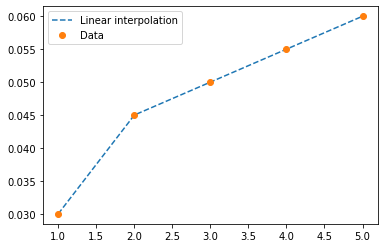

In [66]:
plt.plot(xnew, ylin, '--',label='Linear interpolation')
plt.plot(x,z,"o", label = "Data")
plt.legend(loc='best')
plt.show()

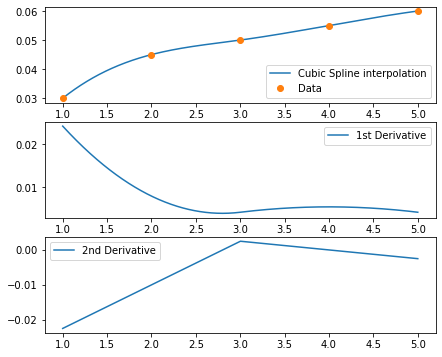

In [67]:
ycub = CubicSpline(x, z)
fig, ax = plt.subplots(3,1,figsize=(7,6))
ax[0].plot(xnew,ycub(xnew),label="Cubic Spline interpolation")
ax[0].plot(x,z,"o",label = "Data")

ax[1].plot(xnew, ycub(xnew, nu=1),label = "1st Derivative")
ax[2].plot(xnew, ycub(xnew, nu=2),label = "2nd Derivative")

for j in range(len(ax)):
    ax[j].legend(loc="best")
    
plt.show()

In [121]:
import requests
from bs4 import BeautifulSoup
r= requests.get("https://www.worldgovernmentbonds.com/country/india/")
soup = BeautifulSoup(r.text,'html.parser')
soup1 = soup.find('table', attrs={"class":"w3-table money pd44 -f15"})
soup1

<table class="w3-table money pd44 -f15" id="table-curve" style="">
<thead class="-f12" style="">
<tr class="pd42">
<th rowspan="2"></th>
<th class="w3-center" rowspan="2" style="vertical-align: bottom;">Residual<br/>Maturity</th>
<th class="w3-center border-bottom" colspan="4">Annualized Yield</th>
<th rowspan="2"></th>
<th class="w3-center border-bottom" colspan="4">Constant Maturity Zero Coupon Price</th>
<th class="w3-center" rowspan="2" style="vertical-align: bottom;">Capital<br/>Growth<br/>of 1 Unit</th>
<th class="w3-center" rowspan="2" style="vertical-align: bottom;">Last<br/>Update</th>
</tr>
<tr class="pd42">
<th class="w3-center">Last</th>
<th class="w3-center" style="">Chg 1M</th>
<th class="w3-center" style="">Chg 6M</th>
<th class="w3-center" style="">Chg 12M</th>
<th class="w3-center">Last</th>
<th class="w3-center" style="">Chg 1M</th>
<th class="w3-center" style="">Chg 6M</th>
<th class="w3-center" style="">Chg 12M</th>
</tr>
</thead>
<tbody>
<tr class="">
<td class="w3

In [160]:
def texttotable(soup1):
    
    def rowtodata(tr, trhead = "td"):
        return [td.get_text(strip=True) for td in tr.find_all(trhead)]
   
    rows = []
    trs = soup1.find_all('tr')
   
    for hdr in trs[:2]:
        rows.append(rowtodata(hdr,'th'))
    for datarow in trs[2:]:
        rows.append(rowtodata(datarow,'td'))
    return rows
df = texttotable(soup1)
df

[['',
  'ResidualMaturity',
  'Annualized Yield',
  '',
  'Constant Maturity Zero Coupon Price',
  'CapitalGrowthof 1 Unit',
  'LastUpdate'],
 ['Last',
  'Chg 1M',
  'Chg 6M',
  'Chg 12M',
  'Last',
  'Chg 1M',
  'Chg 6M',
  'Chg 12M'],
 ['',
  '3 months',
  '6.611%',
  '-4.2 bp',
  '-26.9 bp',
  '-36.9 bp',
  '',
  '98.41',
  '+0.01 %',
  '+0.06 %',
  '+0.08 %',
  '1.016',
  '03 Dec'],
 ['',
  '6 months',
  '6.682%',
  '-2.0 bp',
  '-33.8 bp',
  '-47.8 bp',
  '',
  '96.82',
  '+0.01 %',
  '+0.17 %',
  '+0.23 %',
  '1.032',
  '03 Dec'],
 ['',
  '1 year',
  '6.745%',
  '-8.1 bp',
  '-26.8 bp',
  '-48.4 bp',
  '',
  '93.68',
  '+0.07 %',
  '+0.25 %',
  '+0.45 %',
  '1.067',
  '03 Dec'],
 ['',
  '2 years',
  '6.731%',
  '+3.9 bp',
  '-35.4 bp',
  '-52.0 bp',
  '',
  '87.78',
  '-0.08 %',
  '+0.65 %',
  '+0.97 %',
  '1.139',
  '03 Dec'],
 ['',
  '3 years',
  '6.741%',
  '-11.9 bp',
  '-36.1 bp',
  '-49.6 bp',
  '',
  '82.23',
  '+0.34 %',
  '+1.02 %',
  '+1.41 %',
  '1.216',
  '03 Dec'],
 

In [161]:
raw = pd.DataFrame(df[2:])

In [162]:
tt = pd.DataFrame(df[2:])
tt

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,,3 months,6.611%,-4.2 bp,-26.9 bp,-36.9 bp,,98.41,+0.01 %,+0.06 %,+0.08 %,1.016,03 Dec
1,,6 months,6.682%,-2.0 bp,-33.8 bp,-47.8 bp,,96.82,+0.01 %,+0.17 %,+0.23 %,1.032,03 Dec
2,,1 year,6.745%,-8.1 bp,-26.8 bp,-48.4 bp,,93.68,+0.07 %,+0.25 %,+0.45 %,1.067,03 Dec
3,,2 years,6.731%,+3.9 bp,-35.4 bp,-52.0 bp,,87.78,-0.08 %,+0.65 %,+0.97 %,1.139,03 Dec
4,,3 years,6.741%,-11.9 bp,-36.1 bp,-49.6 bp,,82.23,+0.34 %,+1.02 %,+1.41 %,1.216,03 Dec
5,,4 years,6.743%,-14.0 bp,-36.6 bp,-51.2 bp,,77.03,+0.54 %,+1.38 %,+1.93 %,1.298,03 Dec
6,,5 years,6.744%,-13.6 bp,-36.2 bp,-50.2 bp,,72.16,+0.64 %,+1.71 %,+2.38 %,1.385,03 Dec
7,,6 years,6.741%,-13.1 bp,-31.0 bp,-53.5 bp,,67.61,+0.75 %,+1.76 %,+3.05 %,1.479,03 Dec
8,,7 years,6.864%,-4.5 bp,-24.3 bp,-35.8 bp,,62.83,+0.29 %,+1.60 %,+2.36 %,1.591,03 Dec
9,,8 years,6.889%,-9.3 bp,-22.5 bp,-44.4 bp,,58.69,+0.70 %,+1.70 %,+3.38 %,1.703,03 Dec


In [163]:
df[0] = list(filter(None, df[0])) #you get filter object, hence to avoid convert back to list

s = np.repeat(df[0][1:3],4) #unequal lengthof array will not create multi index using arrays hence using repeat

a = pd.DataFrame(np.repeat(df[0][1:3],4)) #using daatframe
a,s

(                                     0
 0                     Annualized Yield
 1                     Annualized Yield
 2                     Annualized Yield
 3                     Annualized Yield
 4  Constant Maturity Zero Coupon Price
 5  Constant Maturity Zero Coupon Price
 6  Constant Maturity Zero Coupon Price
 7  Constant Maturity Zero Coupon Price,
 array(['Annualized Yield', 'Annualized Yield', 'Annualized Yield',
        'Annualized Yield', 'Constant Maturity Zero Coupon Price',
        'Constant Maturity Zero Coupon Price',
        'Constant Maturity Zero Coupon Price',
        'Constant Maturity Zero Coupon Price'], dtype='<U35'))

In [164]:
k = df[1]  #using array,list
b = pd.DataFrame(df[1]) #using dataframe
b,type(k)

(         0
 0     Last
 1   Chg 1M
 2   Chg 6M
 3  Chg 12M
 4     Last
 5   Chg 1M
 6   Chg 6M
 7  Chg 12M,
 list)

In [165]:
index= tt[1]
index

0     3 months
1     6 months
2       1 year
3      2 years
4      3 years
5      4 years
6      5 years
7      6 years
8      7 years
9      8 years
10     9 years
11    10 years
12    11 years
13    12 years
14    13 years
15    14 years
16    15 years
17    19 years
18    24 years
19    30 years
20    40 years
Name: 1, dtype: object

In [166]:
tt = tt.drop(tt.columns[[0,1,6,11,12]], axis = 1)
tt1 = tt
tt,tt1

(        2         3         4         5      7        8        9         10
 0   6.611%   -4.2 bp  -26.9 bp  -36.9 bp  98.41  +0.01 %  +0.06 %   +0.08 %
 1   6.682%   -2.0 bp  -33.8 bp  -47.8 bp  96.82  +0.01 %  +0.17 %   +0.23 %
 2   6.745%   -8.1 bp  -26.8 bp  -48.4 bp  93.68  +0.07 %  +0.25 %   +0.45 %
 3   6.731%   +3.9 bp  -35.4 bp  -52.0 bp  87.78  -0.08 %  +0.65 %   +0.97 %
 4   6.741%  -11.9 bp  -36.1 bp  -49.6 bp  82.23  +0.34 %  +1.02 %   +1.41 %
 5   6.743%  -14.0 bp  -36.6 bp  -51.2 bp  77.03  +0.54 %  +1.38 %   +1.93 %
 6   6.744%  -13.6 bp  -36.2 bp  -50.2 bp  72.16  +0.64 %  +1.71 %   +2.38 %
 7   6.741%  -13.1 bp  -31.0 bp  -53.5 bp  67.61  +0.75 %  +1.76 %   +3.05 %
 8   6.864%   -4.5 bp  -24.3 bp  -35.8 bp  62.83  +0.29 %  +1.60 %   +2.36 %
 9   6.889%   -9.3 bp  -22.5 bp  -44.4 bp  58.69  +0.70 %  +1.70 %   +3.38 %
 10  6.865%   -9.1 bp  -24.0 bp  -44.8 bp  55.01  +0.75 %  +2.02 %   +3.83 %
 11  6.824%   -8.5 bp  -20.9 bp  -44.7 bp  51.68  +0.80 %  +1.97 %   +4.26 %

In [167]:
new_header = pd.concat([a,b], axis = 1) # single dataframe created two columns
new_header

,0,0
0,Annualized Yield,Last
1,Annualized Yield,Chg 1M
2,Annualized Yield,Chg 6M
3,Annualized Yield,Chg 12M
4,Constant Maturity Zero Coupon Price,Last
5,Constant Maturity Zero Coupon Price,Chg 1M
6,Constant Maturity Zero Coupon Price,Chg 6M
7,Constant Maturity Zero Coupon Price,Chg 12M


In [168]:
header = pd.MultiIndex.from_frame(new_header)
header

MultiIndex([(                   'Annualized Yield',    'Last'),
            (                   'Annualized Yield',  'Chg 1M'),
            (                   'Annualized Yield',  'Chg 6M'),
            (                   'Annualized Yield', 'Chg 12M'),
            ('Constant Maturity Zero Coupon Price',    'Last'),
            ('Constant Maturity Zero Coupon Price',  'Chg 1M'),
            ('Constant Maturity Zero Coupon Price',  'Chg 6M'),
            ('Constant Maturity Zero Coupon Price', 'Chg 12M')],
           names=[0, 0])

In [169]:
tt.columns = header
tt

0  Annualized Yield                                \
0              Last    Chg 1M    Chg 6M   Chg 12M   
0            6.611%   -4.2 bp  -26.9 bp  -36.9 bp   
1            6.682%   -2.0 bp  -33.8 bp  -47.8 bp   
2            6.745%   -8.1 bp  -26.8 bp  -48.4 bp   
3            6.731%   +3.9 bp  -35.4 bp  -52.0 bp   
4            6.741%  -11.9 bp  -36.1 bp  -49.6 bp   
5            6.743%  -14.0 bp  -36.6 bp  -51.2 bp   
6            6.744%  -13.6 bp  -36.2 bp  -50.2 bp   
7            6.741%  -13.1 bp  -31.0 bp  -53.5 bp   
8            6.864%   -4.5 bp  -24.3 bp  -35.8 bp   
9            6.889%   -9.3 bp  -22.5 bp  -44.4 bp   
10           6.865%   -9.1 bp  -24.0 bp  -44.8 bp   
11           6.824%   -8.5 bp  -20.9 bp  -44.7 bp   
12           6.964%   -3.5 bp  -12.2 bp  -37.4 bp   
13           6.972%   -2.7 bp  -16.8 bp  -42.1 bp   
14           6.963%   -3.3 bp  -14.3 bp  -41.0 bp   
15           6.951%   -3.0 bp  -16.7 bp  -44.3 bp   
16           6.944%   +7.2 bp  -12.8 bp  -48.4 bp   
17           6.900%   +1.7 bp  -23.4 bp  -52.2 bp   
18           7.063%  +13.8 bp   -9.5 bp  -41.1 bp   
19           7.115%   +1.1 bp   -5.3 bp  -40.2 bp   
20           7.131%   +0.6 bp   -5.7 bp  -38.5 bp   

0  Constant Maturity Zero Coupon Price                              
0                                 Last   Chg 1M   Chg 6M   Chg 12M  
0                                98.41  +0.01 %  +0.06 %   +0.08 %  
1                                96.82  +0.01 %  +0.17 %   +0.23 %  
2                                93.68  +0.07 %  +0.25 %   +0.45 %  
3                                87.78  -0.08 %  +0.65 %   +0.97 %  
4                                82.23  +0.34 %  +1.02 %   +1.41 %  
5                                77.03  +0.54 %  +1.38 %   +1.93 %  
6                                72.16  +0.64 %  +1.71 %   +2.38 %  
7                                67.61  +0.75 %  +1.76 %   +3.05 %  
8                                62.83  +0.29 %  +1.60 %   +2.36 %  
9                                58.69  +0.70 %  +1.70 %   +3.38 %  
10                               55.01  +0.75 %  +2.02 %   +3.83 %  
11                               51.68  +0.80 %  +1.97 %   +4.26 %  
12                               47.69  +0.38 %  +1.27 %   +3.92 %  
13                               44.54  +0.29 %  +1.90 %   +4.82 %  
14                               41.68  +0.39 %  +1.73 %   +5.09 %  
15                               39.03  +0.39 %  +2.20 %   +5.94 %  
16                               36.53  -1.00 %  +1.81 %   +7.00 %  
17                               28.15  -0.28 %  +4.26 %   +9.70 %  
18                               19.44  -3.04 %  +2.15 %   +9.64 %  
19                               12.72  -0.31 %  +1.52 %  +11.87 %  
20                                6.36  -0.16 %  +2.09 %  +15.43 %

In [170]:
tt[df[0][0]]  = index
tt = tt.set_index(df[0][0])
tt

0                Annualized Yield                                \
0                            Last    Chg 1M    Chg 6M   Chg 12M   
ResidualMaturity                                                  
3 months                   6.611%   -4.2 bp  -26.9 bp  -36.9 bp   
6 months                   6.682%   -2.0 bp  -33.8 bp  -47.8 bp   
1 year                     6.745%   -8.1 bp  -26.8 bp  -48.4 bp   
2 years                    6.731%   +3.9 bp  -35.4 bp  -52.0 bp   
3 years                    6.741%  -11.9 bp  -36.1 bp  -49.6 bp   
4 years                    6.743%  -14.0 bp  -36.6 bp  -51.2 bp   
5 years                    6.744%  -13.6 bp  -36.2 bp  -50.2 bp   
6 years                    6.741%  -13.1 bp  -31.0 bp  -53.5 bp   
7 years                    6.864%   -4.5 bp  -24.3 bp  -35.8 bp   
8 years                    6.889%   -9.3 bp  -22.5 bp  -44.4 bp   
9 years                    6.865%   -9.1 bp  -24.0 bp  -44.8 bp   
10 years                   6.824%   -8.5 bp  -20.9 bp  -44.7 bp   
11 years                   6.964%   -3.5 bp  -12.2 bp  -37.4 bp   
12 years                   6.972%   -2.7 bp  -16.8 bp  -42.1 bp   
13 years                   6.963%   -3.3 bp  -14.3 bp  -41.0 bp   
14 years                   6.951%   -3.0 bp  -16.7 bp  -44.3 bp   
15 years                   6.944%   +7.2 bp  -12.8 bp  -48.4 bp   
19 years                   6.900%   +1.7 bp  -23.4 bp  -52.2 bp   
24 years                   7.063%  +13.8 bp   -9.5 bp  -41.1 bp   
30 years                   7.115%   +1.1 bp   -5.3 bp  -40.2 bp   
40 years                   7.131%   +0.6 bp   -5.7 bp  -38.5 bp   

0                Constant Maturity Zero Coupon Price                    \
0                                               Last   Chg 1M   Chg 6M   
ResidualMaturity                                                         
3 months                                       98.41  +0.01 %  +0.06 %   
6 months                                       96.82  +0.01 %  +0.17 %   
1 year                                         93.68  +0.07 %  +0.25 %   
2 years                                        87.78  -0.08 %  +0.65 %   
3 years                                        82.23  +0.34 %  +1.02 %   
4 years                                        77.03  +0.54 %  +1.38 %   
5 years                                        72.16  +0.64 %  +1.71 %   
6 years                                        67.61  +0.75 %  +1.76 %   
7 years                                        62.83  +0.29 %  +1.60 %   
8 years                                        58.69  +0.70 %  +1.70 %   
9 years                                        55.01  +0.75 %  +2.02 %   
10 years                                       51.68  +0.80 %  +1.97 %   
11 years                                       47.69  +0.38 %  +1.27 %   
12 years                                       44.54  +0.29 %  +1.90 %   
13 years                                       41.68  +0.39 %  +1.73 %   
14 years                                       39.03  +0.39 %  +2.20 %   
15 years                                       36.53  -1.00 %  +1.81 %   
19 years                                       28.15  -0.28 %  +4.26 %   
24 years                                       19.44  -3.04 %  +2.15 %   
30 years                                       12.72  -0.31 %  +1.52 %   
40 years                                        6.36  -0.16 %  +2.09 %   

0                           
0                  Chg 12M  
ResidualMaturity            
3 months           +0.08 %  
6 months           +0.23 %  
1 year             +0.45 %  
2 years            +0.97 %  
3 years            +1.41 %  
4 years            +1.93 %  
5 years            +2.38 %  
6 years            +3.05 %  
7 years            +2.36 %  
8 years            +3.38 %  
9 years            +3.83 %  
10 years           +4.26 %  
11 years           +3.92 %  
12 years           +4.82 %  
13 years           +5.09 %  
14 years           +5.94 %  
15 years           +7.00 %  
19 years           +9.70 %  
24 ye

In [171]:
header2 = pd.MultiIndex.from_arrays([s,k])
header2

MultiIndex([(                   'Annualized Yield',    'Last'),
            (                   'Annualized Yield',  'Chg 1M'),
            (                   'Annualized Yield',  'Chg 6M'),
            (                   'Annualized Yield', 'Chg 12M'),
            ('Constant Maturity Zero Coupon Price',    'Last'),
            ('Constant Maturity Zero Coupon Price',  'Chg 1M'),
            ('Constant Maturity Zero Coupon Price',  'Chg 6M'),
            ('Constant Maturity Zero Coupon Price', 'Chg 12M')],
           )

In [172]:
new_df = pd.DataFrame(df[2:])
new_df = new_df.drop(new_df.columns[[0,1,6,11,12]], axis = 1)
new_df

,2,3,4,5,7,8,9,10
0,6.611%,-4.2 bp,-26.9 bp,-36.9 bp,98.41,+0.01 %,+0.06 %,+0.08 %
1,6.682%,-2.0 bp,-33.8 bp,-47.8 bp,96.82,+0.01 %,+0.17 %,+0.23 %
2,6.745%,-8.1 bp,-26.8 bp,-48.4 bp,93.68,+0.07 %,+0.25 %,+0.45 %
3,6.731%,+3.9 bp,-35.4 bp,-52.0 bp,87.78,-0.08 %,+0.65 %,+0.97 %
4,6.741%,-11.9 bp,-36.1 bp,-49.6 bp,82.23,+0.34 %,+1.02 %,+1.41 %
5,6.743%,-14.0 bp,-36.6 bp,-51.2 bp,77.03,+0.54 %,+1.38 %,+1.93 %
6,6.744%,-13.6 bp,-36.2 bp,-50.2 bp,72.16,+0.64 %,+1.71 %,+2.38 %
7,6.741%,-13.1 bp,-31.0 bp,-53.5 bp,67.61,+0.75 %,+1.76 %,+3.05 %
8,6.864%,-4.5 bp,-24.3 bp,-35.8 bp,62.83,+0.29 %,+1.60 %,+2.36 %
9,6.889%,-9.3 bp,-22.5 bp,-44.4 bp,58.69,+0.70 %,+1.70 %,+3.38 %


In [173]:
new_df.columns = header2
new_df

Annualized Yield                                \
               Last    Chg 1M    Chg 6M   Chg 12M   
0            6.611%   -4.2 bp  -26.9 bp  -36.9 bp   
1            6.682%   -2.0 bp  -33.8 bp  -47.8 bp   
2            6.745%   -8.1 bp  -26.8 bp  -48.4 bp   
3            6.731%   +3.9 bp  -35.4 bp  -52.0 bp   
4            6.741%  -11.9 bp  -36.1 bp  -49.6 bp   
5            6.743%  -14.0 bp  -36.6 bp  -51.2 bp   
6            6.744%  -13.6 bp  -36.2 bp  -50.2 bp   
7            6.741%  -13.1 bp  -31.0 bp  -53.5 bp   
8            6.864%   -4.5 bp  -24.3 bp  -35.8 bp   
9            6.889%   -9.3 bp  -22.5 bp  -44.4 bp   
10           6.865%   -9.1 bp  -24.0 bp  -44.8 bp   
11           6.824%   -8.5 bp  -20.9 bp  -44.7 bp   
12           6.964%   -3.5 bp  -12.2 bp  -37.4 bp   
13           6.972%   -2.7 bp  -16.8 bp  -42.1 bp   
14           6.963%   -3.3 bp  -14.3 bp  -41.0 bp   
15           6.951%   -3.0 bp  -16.7 bp  -44.3 bp   
16           6.944%   +7.2 bp  -12.8 bp  -48.4 bp   
17           6.900%   +1.7 bp  -23.4 bp  -52.2 bp   
18           7.063%  +13.8 bp   -9.5 bp  -41.1 bp   
19           7.115%   +1.1 bp   -5.3 bp  -40.2 bp   
20           7.131%   +0.6 bp   -5.7 bp  -38.5 bp   

   Constant Maturity Zero Coupon Price                              
                                  Last   Chg 1M   Chg 6M   Chg 12M  
0                                98.41  +0.01 %  +0.06 %   +0.08 %  
1                                96.82  +0.01 %  +0.17 %   +0.23 %  
2                                93.68  +0.07 %  +0.25 %   +0.45 %  
3                                87.78  -0.08 %  +0.65 %   +0.97 %  
4                                82.23  +0.34 %  +1.02 %   +1.41 %  
5                                77.03  +0.54 %  +1.38 %   +1.93 %  
6                                72.16  +0.64 %  +1.71 %   +2.38 %  
7                                67.61  +0.75 %  +1.76 %   +3.05 %  
8                                62.83  +0.29 %  +1.60 %   +2.36 %  
9                                58.69  +0.70 %  +1.70 %   +3.38 %  
10                               55.01  +0.75 %  +2.02 %   +3.83 %  
11                               51.68  +0.80 %  +1.97 %   +4.26 %  
12                               47.69  +0.38 %  +1.27 %   +3.92 %  
13                               44.54  +0.29 %  +1.90 %   +4.82 %  
14                               41.68  +0.39 %  +1.73 %   +5.09 %  
15                               39.03  +0.39 %  +2.20 %   +5.94 %  
16                               36.53  -1.00 %  +1.81 %   +7.00 %  
17                               28.15  -0.28 %  +4.26 %   +9.70 %  
18                               19.44  -3.04 %  +2.15 %   +9.64 %  
19                               12.72  -0.31 %  +1.52 %  +11.87 %  
20                                6.36  -0.16 %  +2.09 %  +15.43 %

In [174]:
index2 = {df[0][0]:raw[1]}
index2

{'ResidualMaturity': 0     3 months
 1     6 months
 2       1 year
 3      2 years
 4      3 years
 5      4 years
 6      5 years
 7      6 years
 8      7 years
 9      8 years
 10     9 years
 11    10 years
 12    11 years
 13    12 years
 14    13 years
 15    14 years
 16    15 years
 17    19 years
 18    24 years
 19    30 years
 20    40 years
 Name: 1, dtype: object}

In [175]:
type(new_df.columns[[0]])

pandas.core.indexes.multi.MultiIndex

In [176]:
new_df = pd.concat([pd.DataFrame(index2),new_df], ignore_index = False, axis =1)
new_df = new_df.set_index(list(new_df.columns[[0]]))
new_df

,"(Annualized Yield, Last)","(Annualized Yield, Chg 1M)","(Annualized Yield, Chg 6M)","(Annualized Yield, Chg 12M)","(Constant Maturity Zero Coupon Price, Last)","(Constant Maturity Zero Coupon Price, Chg 1M)","(Constant Maturity Zero Coupon Price, Chg 6M)","(Constant Maturity Zero Coupon Price, Chg 12M)"
ResidualMaturity,,,,,,,,
3 months,6.611%,-4.2 bp,-26.9 bp,-36.9 bp,98.41,+0.01 %,+0.06 %,+0.08 %
6 months,6.682%,-2.0 bp,-33.8 bp,-47.8 bp,96.82,+0.01 %,+0.17 %,+0.23 %
1 year,6.745%,-8.1 bp,-26.8 bp,-48.4 bp,93.68,+0.07 %,+0.25 %,+0.45 %
2 years,6.731%,+3.9 bp,-35.4 bp,-52.0 bp,87.78,-0.08 %,+0.65 %,+0.97 %
3 years,6.741%,-11.9 bp,-36.1 bp,-49.6 bp,82.23,+0.34 %,+1.02 %,+1.41 %
4 years,6.743%,-14.0 bp,-36.6 bp,-51.2 bp,77.03,+0.54 %,+1.38 %,+1.93 %
5 years,6.744%,-13.6 bp,-36.2 bp,-50.2 bp,72.16,+0.64 %,+1.71 %,+2.38 %
6 years,6.741%,-13.1 bp,-31.0 bp,-53.5 bp,67.61,+0.75 %,+1.76 %,+3.05 %
7 years,6.864%,-4.5 bp,-24.3 bp,-35.8 bp,62.83,+0.29 %,+1.60 %,+2.36 %
